In [11]:
import numpy as np
import matplotlib.pyplot as plt
import ripser
import persim
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist, squareform
import gudhi as gd
from gudhi.representations import Landscape, Silhouette, PersistenceImage
import tadasets
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import networkx as nx
import nibabel as nib
import os
from tqdm import tqdm
from skimage.transform import resize
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, roc_curve
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

target_shape = (128, 128, 64)

In [7]:
data_dir = '/Users/dasidorov03/PycharmProjects/dploma_4_course/IXI-T1/data/'
target_shape = (128, 128, 64)

def load_mri_images(data_dir):
    images = []
    file_list = [f for f in os.listdir(data_dir) if f.endswith('.nii') or f.endswith('.nii.gz')]
    
    for file_name in tqdm(file_list, desc="Загрузка MRI-изображений"):
        img_path = os.path.join(data_dir, file_name)
        img = nib.load(img_path)
        img_data = img.get_fdata()

        img_resized = resize(img_data, target_shape, anti_aliasing=True)

        img_vector = img_resized.flatten()
        images.append(img_vector)
    
    return np.array(images)

mri_data = load_mri_images(data_dir)


Загрузка MRI-изображений:   0%|          | 0/582 [00:00<?, ?it/s]

Загрузка MRI-изображений: 100%|██████████| 582/582 [01:59<00:00,  4.88it/s]


In [27]:
def create_synthetic_anomalies_mri(mri_data, anomaly_ratio=0.2, anomaly_scale=5.0, random_state=42):
    """
    Создает синтетические аномалии в МРТ-снимках.
    
    Args:
        mri_data: Набор МРТ-снимков в формате (n_samples, n_features)
        anomaly_ratio: Доля аномальных образцов
        anomaly_scale: Масштаб аномалий
        random_state: Случайное состояние для воспроизводимости
        
    Returns:
        МРТ-снимки с аномалиями и индексы аномальных образцов
    """
    np.random.seed(random_state)
    mri_data_with_anomalies = mri_data.copy()
    n_samples = mri_data.shape[0]
    
    n_anomalies = int(n_samples * anomaly_ratio)
    anomaly_indices = np.random.choice(n_samples, n_anomalies, replace=False)
    
    for idx in anomaly_indices:
        img_3d = mri_data[idx].reshape(target_shape)
        anomaly_type = np.random.choice(['local_bright', 'local_dark', 'noise', 'structured'])
        
        if anomaly_type == 'local_bright':
            # Создаем яркое пятно в случайном месте
            x_center = np.random.randint(20, target_shape[0]-20)
            y_center = np.random.randint(20, target_shape[1]-20)
            z_center = np.random.randint(10, target_shape[2]-10)
            
            radius = np.random.randint(5, 15)
            
            # Создаем сферическую аномалию
            x, y, z = np.indices((target_shape))
            dist = np.sqrt((x - x_center)**2 + (y - y_center)**2 + (z - z_center)**2)
            anomaly_mask = dist <= radius
            
            img_3d[anomaly_mask] *= anomaly_scale
            
        elif anomaly_type == 'local_dark':
            # Создаем темное пятно в случайном месте
            x_center = np.random.randint(20, target_shape[0]-20)
            y_center = np.random.randint(20, target_shape[1]-20)
            z_center = np.random.randint(10, target_shape[2]-10)
            
            radius = np.random.randint(5, 15)
            
            # Создаем сферическую аномалию
            x, y, z = np.indices((target_shape))
            dist = np.sqrt((x - x_center)**2 + (y - y_center)**2 + (z - z_center)**2)
            anomaly_mask = dist <= radius
            
            img_3d[anomaly_mask] /= anomaly_scale
            
        elif anomaly_type == 'noise':
            # Добавляем шум на всё изображение
            noise = np.random.randn(*target_shape) * (np.max(img_3d) - np.min(img_3d)) * 0.1
            img_3d += noise
            
        else:  # 'structured'
            # Создаем структурированную аномалию (например, полосы)
            direction = np.random.choice(['x', 'y', 'z'])
            
            if direction == 'x':
                x_start = np.random.randint(0, target_shape[0] - 1)
                width = np.random.randint(5, 20)
                x_end = min(x_start + width, target_shape[0])
                img_3d[x_start:x_end, :, :] *= anomaly_scale
                
            elif direction == 'y':
                y_start = np.random.randint(0, target_shape[1] - 1)
                width = np.random.randint(5, 20)
                y_end = min(y_start + width, target_shape[1])
                img_3d[:, y_start:y_end, :] *= anomaly_scale
                
            else:  # 'z'
                z_start = np.random.randint(0, target_shape[2] - 1)
                width = np.random.randint(3, 10)
                z_end = min(z_start + width, target_shape[2])
                img_3d[:, :, z_start:z_end] *= anomaly_scale
        
        mri_data_with_anomalies[idx] = img_3d.flatten()
    
    return mri_data_with_anomalies, anomaly_indices

def estimate_curvature(data, n_neighbors=15):
    """
    Оценивает кривизну многообразия данных используя локальную аппроксимацию.
    
    Args:
        data: Данные формы (n_samples, n_features)
        n_neighbors: Количество соседей для локальной аппроксимации
        
    Returns:
        Массив оценок кривизны для каждой точки
    """
    n_samples, n_features = data.shape
    
    nbrs = NearestNeighbors(n_neighbors=n_neighbors+1).fit(data)
    distances, indices = nbrs.kneighbors(data)
    
    indices = indices[:, 1:]
    distances = distances[:, 1:]
    
    # Оценка кривизны через PCA и отношение собственных значений
    curvatures = np.zeros(n_samples)
    
    for i in tqdm(range(n_samples), desc="Оценка кривизны"):
        neighborhood = data[indices[i]]
        center = data[i]
        
        centered_neighbors = neighborhood - center
        U, S, Vt = np.linalg.svd(centered_neighbors, full_matrices=False)
        
        # Отношение минимального ненулевого собственного значения к максимальному
        # характеризует "сплющенность" многообразия
        eigenvalues = S
        
        if len(eigenvalues) > 1:
            min_nonzero_eig = np.min(eigenvalues[eigenvalues > 1e-10]) if any(eigenvalues > 1e-10) else 1e-10
            max_eig = np.max(eigenvalues)
            flatness = min_nonzero_eig / (max_eig + 1e-10)
            
            # Формула для оценки кривизны: C(x_i) = 1 - λ_min/λ_max
            # Чем ближе к 1, тем больше кривизна
            curvatures[i] = 1.0 - flatness
        else:
            curvatures[i] = 0.0
    
    return curvatures

def compute_reconstruction_error(data, n_neighbors=15, n_components=None):
    """
    Вычисляет ошибку реконструкции для оценки кривизны.
    
    Args:
        data: Данные формы (n_samples, n_features)
        n_neighbors: Количество соседей для локальной аппроксимации
        n_components: Количество главных компонент (если None, определяется автоматически)
        
    Returns:
        Массив ошибок реконструкции для каждой точки
    """
    n_samples, n_features = data.shape
    
    if n_components is None:
        # По умолчанию используем небольшое число компонент из-за высокой размерности
        n_components = min(50, n_neighbors - 1)
        n_components = max(n_components, 1)  
    
    nbrs = NearestNeighbors(n_neighbors=n_neighbors+1).fit(data)
    distances, indices = nbrs.kneighbors(data)
    indices = indices[:, 1:]
    reconstruction_errors = np.zeros(n_samples)
    
    for i in tqdm(range(n_samples), desc="Вычисление ошибок реконструкции"):
        neighborhood = data[indices[i]]
        center = data[i]   
        centered_neighbors = neighborhood - center
        
        try:
            pca = PCA(n_components=n_components)
            projection = pca.fit_transform(centered_neighbors)
            
            reconstruction = pca.inverse_transform(projection)
            
            # Ошибка реконструкции: E(x_i) = (1/k) Σ ||x_j - x̂_j||²
            reconstruction_error = np.mean(np.sum((centered_neighbors - reconstruction)**2, axis=1))
            reconstruction_errors[i] = reconstruction_error
        except:
            reconstruction_errors[i] = 0
    
    if np.max(reconstruction_errors) > np.min(reconstruction_errors):
        reconstruction_errors = (reconstruction_errors - np.min(reconstruction_errors)) / (np.max(reconstruction_errors) - np.min(reconstruction_errors))
    
    return reconstruction_errors

def detect_anomalies_with_curvature(data, curvature_weight=0.5, reconstruction_weight=0.5, n_neighbors=15):
    """
    Обнаруживает аномалии с использованием кривизны многообразия.
    
    Args:
        data: Исходные данные
        curvature_weight: Вес оценки кривизны через собственные значения
        reconstruction_weight: Вес оценки через ошибку реконструкции
        n_neighbors: Количество соседей для локальной аппроксимации
        
    Returns:
        Оценки аномальности для каждой точки
    """
    
    curvatures = estimate_curvature(data, n_neighbors)
    reconstruction_errors = compute_reconstruction_error(data, n_neighbors)
    combined_scores = curvature_weight * curvatures + reconstruction_weight * reconstruction_errors
    
    return combined_scores

def evaluate_curvature_anomaly_detection_mri(mri_data, num_samples=20, anomaly_ratio=0.3, 
                                           anomaly_scale=5.0, n_neighbors=15, random_state=42):
    """
    Оценивает эффективность обнаружения аномалий в МРТ-снимках с использованием кривизны многообразия.
    
    Args:
        mri_data: Исходные МРТ-данные
        num_samples: Количество образцов для анализа (ограничиваем для ускорения)
        anomaly_ratio: Доля аномальных образцов
        anomaly_scale: Масштаб аномалий
        n_neighbors: Количество соседей для локальной аппроксимации
        random_state: Случайное состояние для воспроизводимости
        
    Returns:
        Метрики ROC AUC и PR AUC, а также оценки аномальности и истинные метки
    """
    if num_samples < len(mri_data):
        np.random.seed(random_state)
        indices = np.random.choice(len(mri_data), num_samples, replace=False)
        mri_subset = mri_data[indices]
    else:
        mri_subset = mri_data
    
    mri_with_anomalies, anomaly_indices = create_synthetic_anomalies_mri(
        mri_subset, anomaly_ratio=anomaly_ratio, anomaly_scale=anomaly_scale, random_state=random_state
    )
    
    
    # Метки: 1 для аномалий, 0 для нормальных
    true_labels = np.zeros(len(mri_subset))
    true_labels[anomaly_indices] = 1
    
    anomaly_scores = detect_anomalies_with_curvature(mri_with_anomalies, 
                                                   curvature_weight=0.5, 
                                                   reconstruction_weight=0.5,
                                                   n_neighbors=min(n_neighbors, len(mri_subset)-1))
    
    roc_auc = roc_auc_score(true_labels, anomaly_scores)
    precision, recall, _ = precision_recall_curve(true_labels, anomaly_scores)
    pr_auc = auc(recall, precision)
    
    print(f"\nРезультаты обнаружения аномалий с помощью кривизны:")
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"PR AUC: {pr_auc:.4f}")
    
    visualize_performance_curves(true_labels, anomaly_scores, roc_auc, pr_auc)
    
    return roc_auc, pr_auc, anomaly_scores, true_labels

def visualize_performance_curves(true_labels, anomaly_scores, roc_auc, pr_auc):
    """
    Визуализирует только кривые ROC-AUC и PR-AUC для оценки производительности.
    
    Args:
        true_labels: Истинные метки (1 для аномалий, 0 для нормальных)
        anomaly_scores: Оценки аномальности
        roc_auc: Значение ROC AUC
        pr_auc: Значение PR AUC
    """
    plt.figure(figsize=(12, 5))
    
    # 1. ROC-кривая
    plt.subplot(1, 2, 1)
    fpr, tpr, _ = roc_curve(true_labels, anomaly_scores)
    plt.plot(fpr, tpr, lw=2)
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'ROC Curve (AUC = {roc_auc:.4f})', fontsize=14)
    plt.grid(True, alpha=0.3)
    
    # 2. PR-кривая
    plt.subplot(1, 2, 2)
    precision, recall, _ = precision_recall_curve(true_labels, anomaly_scores)
    plt.plot(recall, precision, lw=2)
    
    # Добавим горизонтальную линию, показывающую случайное угадывание
    baseline = np.sum(true_labels) / len(true_labels)
    plt.axhline(y=baseline, color='k', linestyle='--', lw=2, 
               label=f'Random (precision = {baseline:.2f})')
    
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title(f'PR Curve (AUC = {pr_auc:.4f})', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('mri_curvature_performance.png', dpi=300, bbox_inches='tight')
    plt.show()


Вычисление ошибок реконструкции: 100%|██████████| 50/50 [00:08<00:00,  5.63it/s]



Результаты обнаружения аномалий с помощью кривизны:
ROC AUC: 0.7943
PR AUC: 0.7251


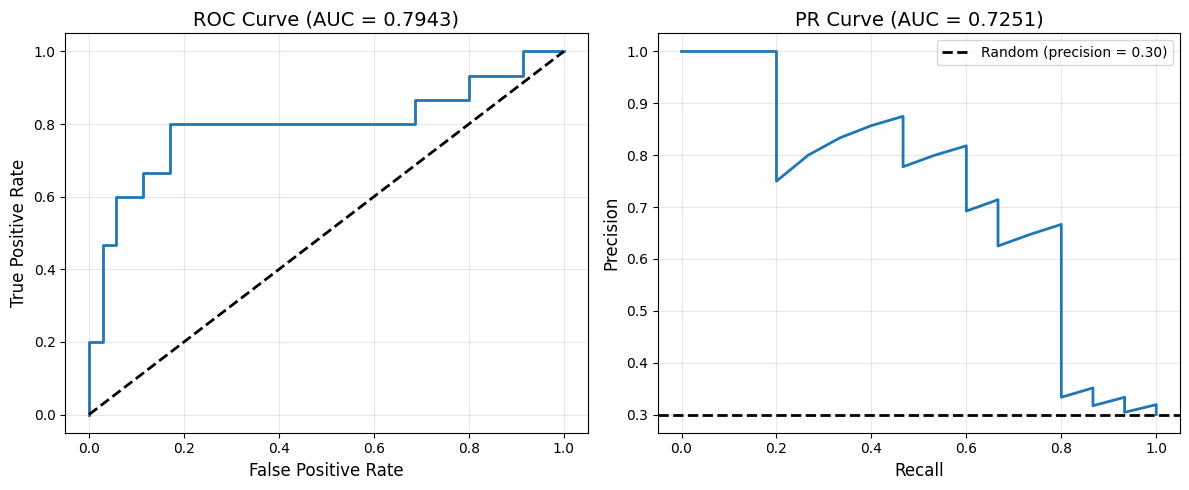

In [28]:
if __name__ == "__main__":
    
    # Параметры эксперимента
    params = {
        'num_samples': 50,        # Ограничиваем количество снимков для анализа
        'anomaly_ratio': 0.3,     # Доля аномалий
        'anomaly_scale': 300.0,   # Масштаб аномалий
        'n_neighbors': 5,         # Количество соседей для анализа локальной геометрии
        'random_state': 42        # Случайное состояние для воспроизводимости
    }
    
    roc_auc, pr_auc, scores, true_labels = evaluate_curvature_anomaly_detection_mri(mri_data, **params)